In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
import random
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns



In [2]:
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [3]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
print(f"Training images shape: {train_images.shape}, Training labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}, Test labels shape: {test_labels.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28), Training labels shape: (60000,)
Test images shape: (10000, 28, 28), Test labels shape: (10000,)


In [4]:
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

In [5]:
train_images = train_images.reshape(-1, 28, 28, 1)
test_images = test_images.reshape(-1, 28, 28, 1)

In [6]:
cnn_model = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
training_history = cnn_model.fit(
    train_images, train_labels,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.8779 - loss: 0.4133 - val_accuracy: 0.9813 - val_loss: 0.0629
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 36s 48ms/step - accuracy: 0.9811 - loss: 0.0597 - val_accuracy: 0.9814 - val_loss: 0.0603
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 36s 49ms/step - accuracy: 0.9883 - loss: 0.0364 - val_accuracy: 0.9875 - val_loss: 0.0434
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 36s 48ms/step - accuracy: 0.9926 - loss: 0.0253 - val_accuracy: 0.9877 - val_loss: 0.0444
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.9930 - loss: 0.0209 - val_accuracy: 0.9887 - val_loss: 0.0375


In [9]:
eval_loss, eval_acc = cnn_model.evaluate(test_images, test_labels)
print(f"Test Accuracy: {eval_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9858 - loss: 0.0435
Test Accuracy: 0.9886


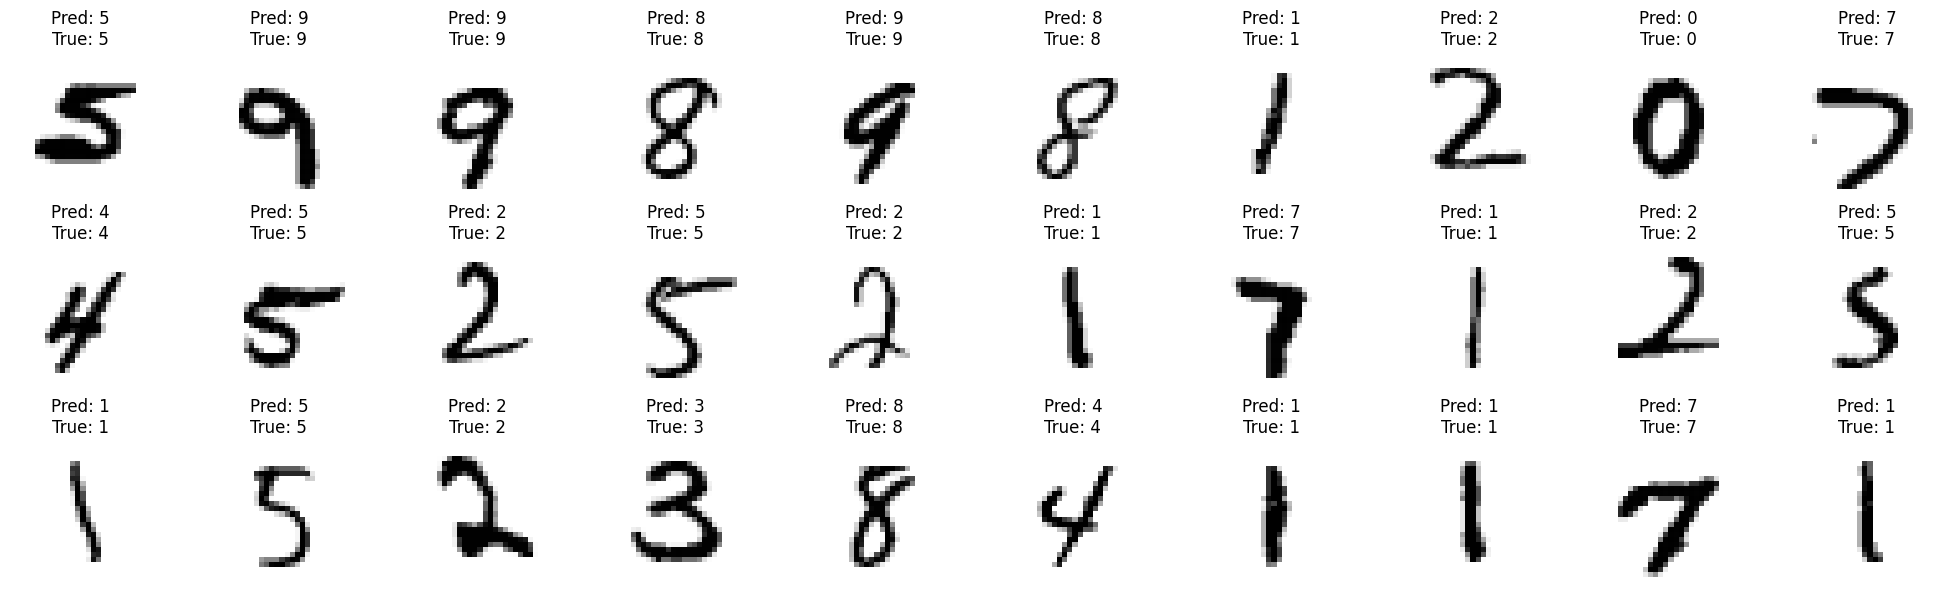

In [10]:
num_rows, num_cols = 3, 10
plt.figure(figsize=(20, 6))
for idx in range(num_rows * num_cols):
    sample_idx = random.randint(0, test_images.shape[0] - 1)
    sample_img = test_images[sample_idx].reshape(28, 28)
    predicted_label = np.argmax(cnn_model.predict(test_images[sample_idx:sample_idx + 1], verbose=0))
    plt.subplot(num_rows, num_cols, idx + 1)
    plt.imshow(sample_img, cmap='gray_r')
    plt.title(f"Pred: {predicted_label}\nTrue: {test_labels[sample_idx]}")
    plt.axis('off')
plt.tight_layout()
plt.show()